In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import files

uploaded = files.upload()


Saving AQI_Data_Science_Project.ipynb to AQI_Data_Science_Project.ipynb


In [11]:
import os

print("Files in current folder:")
print(os.listdir())

Files in current folder:
['.config', 'AQI_Data_Science_Project.ipynb', 'sample_data']


In [20]:
from google.colab import files
import pandas as pd

# Upload file
uploaded = files.upload()

# Automatically read the uploaded CSV
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset Loaded Successfully")
print("Filename:", filename)
print("Dataset Shape:", df.shape)

df.head()

Saving global_urban_aqi_dataset.csv to global_urban_aqi_dataset.csv
Dataset Loaded Successfully
Filename: global_urban_aqi_dataset.csv
Dataset Shape: (14184, 13)


,City,Country,Date,AQI,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind_Speed
0,Bangkok,Thailand,2019-04-25,145.99,53.12,90.86,22.88,20.63,42.87,29.27,10.3,65.0,5.3
1,Mexico City,Mexico,2019-07-18,189.57,88.63,152.78,22.43,19.15,60.82,48.39,19.2,46.4,8.7
2,Cairo,Egypt,2024-05-23,125.34,57.52,107.66,14.76,17.22,31.12,23.56,12.0,65.2,4.4
3,Shanghai,China,2015-02-19,247.53,93.99,171.95,45.34,42.73,58.79,56.00,23.8,67.4,4.3
4,Tokyo,Japan,2025-10-16,41.82,20.31,17.83,5.66,5.12,12.72,1.39,19.7,50.4,10.1


In [21]:
def aqi_state(aqi):
    if aqi <= 100:
        return "Low AQI"
    elif aqi <= 200:
        return "Medium AQI"
    else:
        return "High AQI"

df['AQI_State'] = df['AQI'].apply(aqi_state)

df[['AQI', 'AQI_State']].head()

,AQI,AQI_State
0,145.99,Medium AQI
1,189.57,Medium AQI
2,125.34,Medium AQI
3,247.53,High AQI
4,41.82,Low AQI


In [22]:
state_mapping = {
    "Low AQI":0,
    "Medium AQI":1,
    "High AQI":2
}

df['State'] = df['AQI_State'].map(state_mapping)

df[['AQI_State','State']].head()

,AQI_State,State
0,Medium AQI,1
1,Medium AQI,1
2,Medium AQI,1
3,High AQI,2
4,Low AQI,0


In [23]:
actions = {
    0:"No Restriction",
    1:"Partial Restriction",
    2:"High-Pollution Alert"
}

print(actions)

{0: 'No Restriction', 1: 'Partial Restriction', 2: 'High-Pollution Alert'}


In [24]:
reward_table = np.array([
    [10, -2, -5],   # Low AQI
    [-6, 10, 2],    # Medium AQI
    [-10, -3, 10]   # High AQI
])

reward_table

array([[ 10,  -2,  -5],
       [ -6,  10,   2],
       [-10,  -3,  10]])

In [25]:
num_states = 3
num_actions = 3

Q = np.zeros((num_states, num_actions))

print(Q)

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [26]:
alpha = 0.1
gamma = 0.9
epsilon = 0.1
episodes = 500

rewards_per_episode = []

In [27]:
for episode in range(episodes):

    total_reward = 0

    for state in df['State']:

        if np.random.uniform(0,1) < epsilon:
            action = np.random.randint(num_actions)
        else:
            action = np.argmax(Q[state])

        reward = reward_table[state, action]

        next_state = state

        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        total_reward += reward

    rewards_per_episode.append(total_reward)

print("Training Completed")

Training Completed


In [28]:
q_table = pd.DataFrame(
    Q,
    columns=[
        "No Restriction",
        "Partial Restriction",
        "High-Pollution Alert"
    ],
    index=[
        "Low AQI",
        "Medium AQI",
        "High AQI"
    ]
)

q_table

,No Restriction,Partial Restriction,High-Pollution Alert
Low AQI,100.0,88.0,85.0
Medium AQI,84.0,100.0,92.0
High AQI,80.0,87.0,100.0


In [29]:
best_actions = np.argmax(Q, axis=1)

states = ["Low AQI","Medium AQI","High AQI"]

print("Final Learned Policy\n")

for i, state in enumerate(states):
    print(state, "->", actions[best_actions[i]])

Final Learned Policy

Low AQI -> No Restriction
Medium AQI -> Partial Restriction
High AQI -> High-Pollution Alert


In [30]:
average_reward = np.mean(rewards_per_episode)

print("Average Reward After Training:", round(average_reward,2))

Average Reward After Training: 129351.52


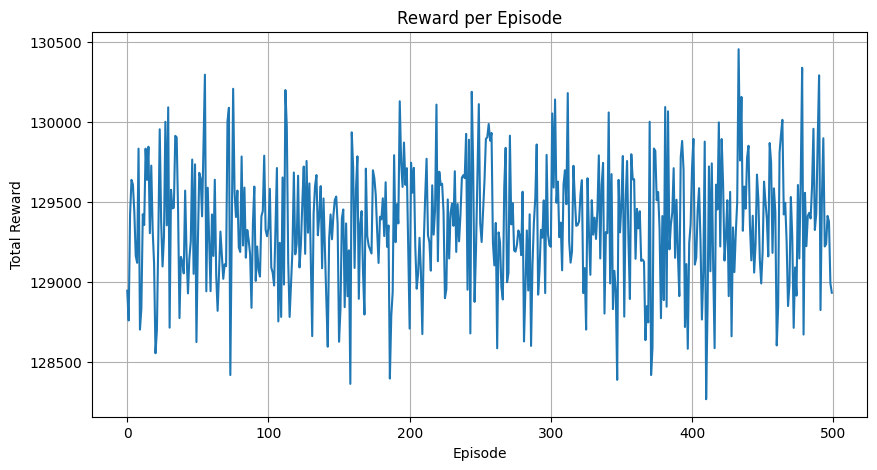

In [31]:
plt.figure(figsize=(10,5))
plt.plot(rewards_per_episode)
plt.title("Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

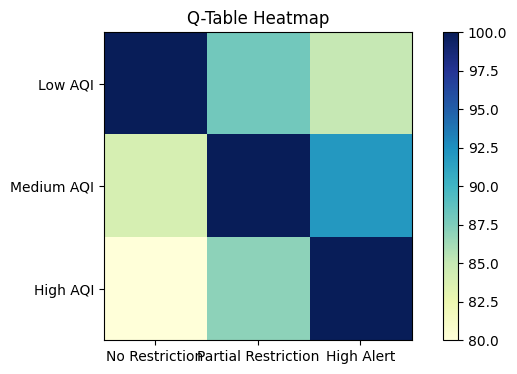

In [32]:
plt.figure(figsize=(8,4))

plt.imshow(Q, cmap='YlGnBu')

plt.colorbar()

plt.xticks(
    [0,1,2],
    ["No Restriction","Partial Restriction","High Alert"]
)

plt.yticks(
    [0,1,2],
    ["Low AQI","Medium AQI","High AQI"]
)

plt.title("Q-Table Heatmap")

plt.show()

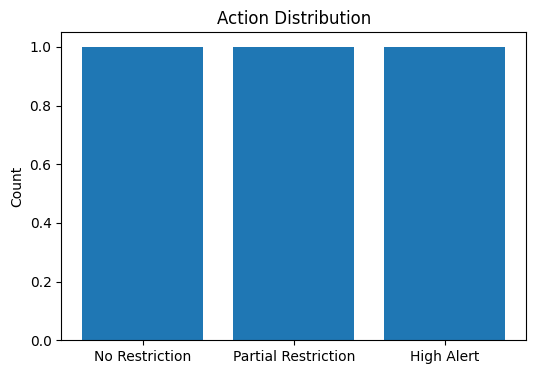

In [33]:
action_counts = np.bincount(best_actions)

plt.figure(figsize=(6,4))

plt.bar(
    ["No Restriction","Partial Restriction","High Alert"],
    action_counts
)

plt.title("Action Distribution")

plt.ylabel("Count")

plt.show()